# **Outlier_Detection_using Z_score_Method**

### **Import libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Load the Dataset**

In [16]:
df = pd.read_csv('placement.csv')

In [17]:
df.sample(5)

,cgpa,placement_exam_marks,placed
919,6.59,21.0,0
123,6.25,52.0,0
716,7.06,19.0,1
261,7.17,11.0,1
550,6.62,38.0,1


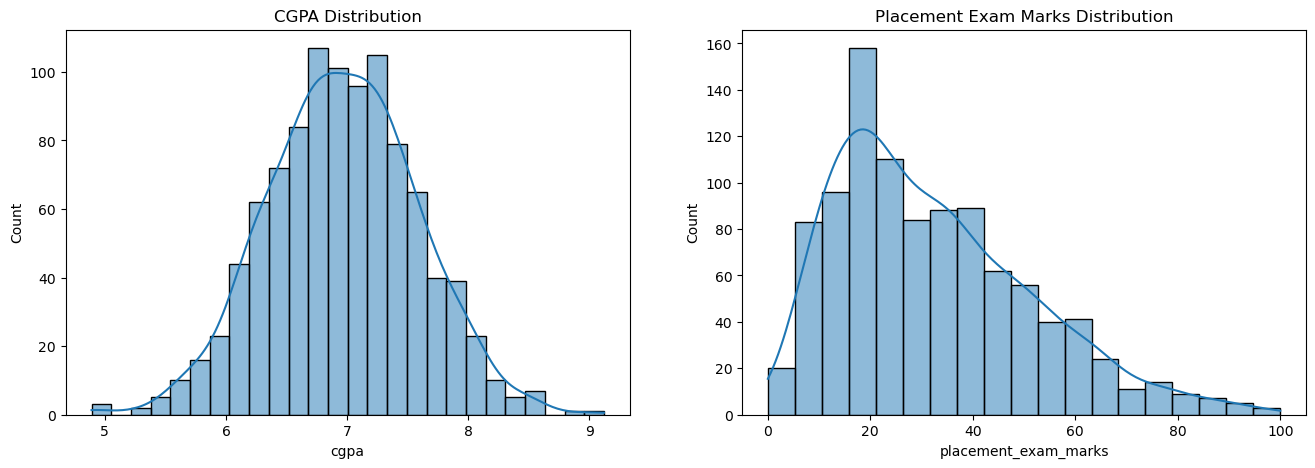

In [18]:
plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
sns.histplot(df['cgpa'], kde=True)
plt.title('CGPA Distribution')

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'], kde=True)
plt.title('Placement Exam Marks Distribution')

plt.show()

In [19]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

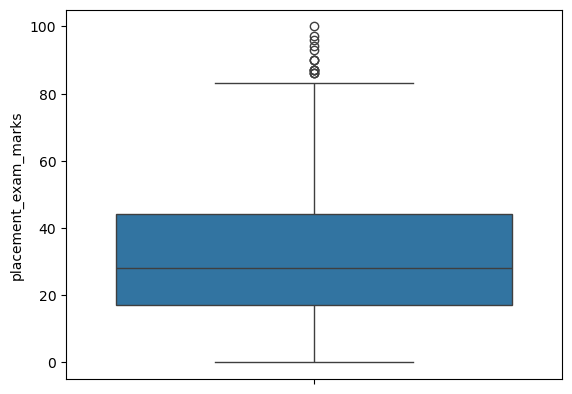

In [20]:
sns.boxplot(df['placement_exam_marks'])

In [23]:
# Finding the IQR
Q1 = df['placement_exam_marks'].quantile(0.25)
Q3 = df['placement_exam_marks'].quantile(0.75)
IQR = Q3 - Q1

In [24]:
Q1

np.float64(17.0)

In [25]:
Q3

np.float64(44.0)

In [26]:
IQR

np.float64(27.0)

In [27]:
upper_limit = Q1 + 1.5 * IQR
lower_limit = Q3 - 1.5 * IQR

In [28]:
print("Upper limit",upper_limit)
print("Lower limit",lower_limit)

Upper limit 57.5
Lower limit 3.5


## **Finding Outliers**

In [29]:
df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
25,6.28,58.0,1
40,6.60,86.0,1
42,7.46,71.0,1
43,7.85,63.0,0
...,...,...,...
966,6.24,72.0,1
967,7.35,59.0,0
987,6.77,62.0,0
994,6.48,63.0,0


In [30]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed
74,6.16,3.0,1
117,7.11,0.0,1
219,5.48,3.0,0
701,6.74,2.0,1
863,8.04,2.0,1
943,7.36,2.0,0


## **Trimming_Approach**

In [31]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [32]:
new_df.shape

(886, 3)

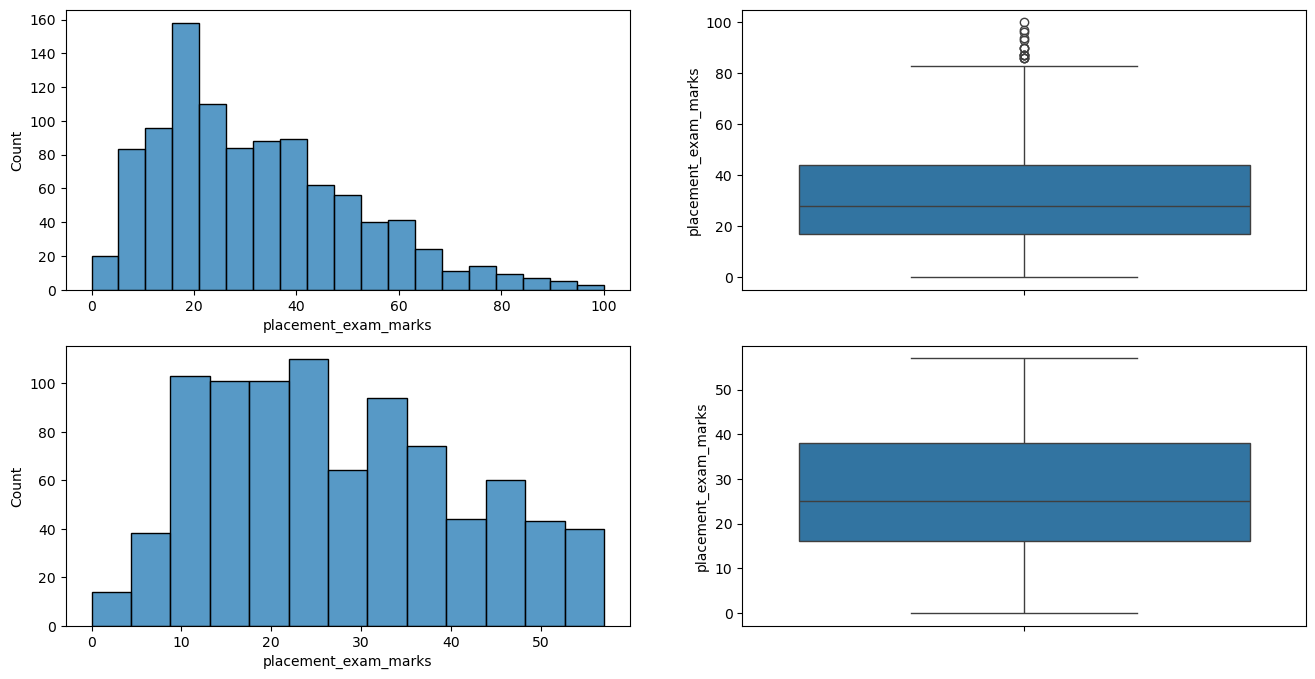

In [34]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df['placement_exam_marks'])

plt.show()

## **Capping**

In [35]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [37]:
new_df_cap.shape

(1000, 3)

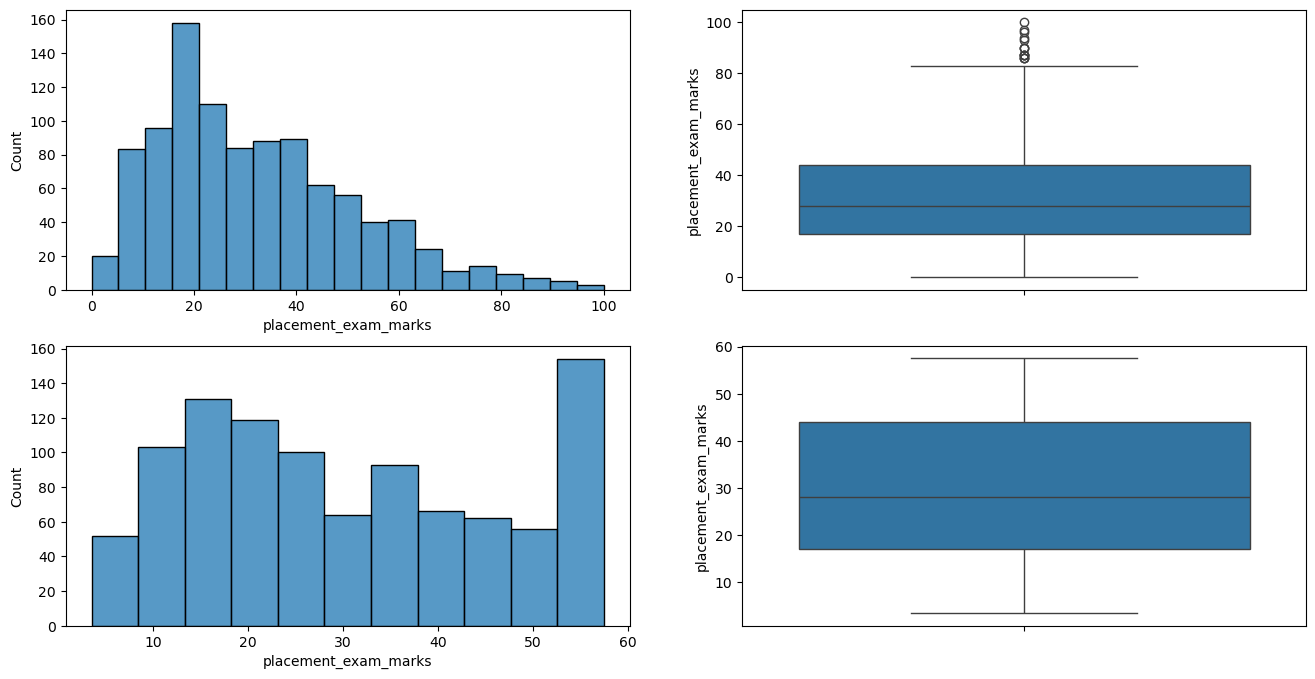

In [38]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'])

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'])

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()